<a href="https://colab.research.google.com/github/techasit239/DADS7202_PigPicture/blob/main/FreshCheck_Thai_TestPrep_and_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FreshCheck — Thai Test Set Prep + EfficientNet-B0 Inference

**วัตถุประสงค์:** เตรียม Thai retail test set จาก Drive structure แล้วรัน EfficientNet-B0 inference

**Input structure ใน Drive:**
```
MyDrive/FreshCheck/thai_raw/
├── indoor/
│   ├── 0hr/  ← Fresh
│   ├── 1hr/  ← Fresh
│   ├── 2hr/  ← Fresh
│   ├── 3hr/  ← Half-Fresh
│   ├── 4hr/  ← Half-Fresh
│   ├── 5hr/  ← Half-Fresh
│   ├── 6hr/  ← Spoiled
│   └── 7hr/  ← Spoiled
└── outdoor/
    └── (same structure)
```

**Label mapping:**
- 0hr–2hr → `FR` (Fresh)
- 3hr–5hr → `HF` (Half-Fresh)
- 6hr–7hr → `SP` (Spoiled)

**Output:**
- รูปที่ rename แล้วใน `MyDrive/FreshCheck/thai_test/`
- `thai_test_manifest.csv` พร้อม piece_id, label, path
- `thai_test_predictions.csv` ผลจาก EfficientNet-B0

## 0 · Mount Drive + Config

⚙️ **แก้ค่าใน cell นี้เพียงที่เดียว**

In [19]:
from google.colab import drive
drive.mount('/content/drive')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CONFIG — แก้ path ตามจริงของแต่ละคน
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# โฟลเดอร์รูปดิบ (มี indoor/ outdoor/ อยู่ข้างใน)
RAW_ROOT = '/content/drive/MyDrive/หมูแยกชั่วโมง_JPG'

# โฟลเดอร์ output สำหรับรูปที่ rename แล้ว
TEST_OUT  = '/content/drive/MyDrive/FreshCheck/thai_test'

# โฟลเดอร์ที่เก็บ Phase 1 model checkpoint (จาก Phase 1 notebook)
MODEL_DIR = '/content/drive/MyDrive/FreshCheck/phase1_outputs'
MODEL_NAME = 'efficientnet_b0_best.pth'   # ชื่อไฟล์ .pth จริงๆ

# วันที่ถ่ายรูป (ใส่จริง เพื่อ filename ถูกต้อง)
CAPTURE_DATE = '20260615'   # YYYYMMDD
CAPTURE_TIME = '1000'       # HHMM (approximate)

# SourceType: PK=Packaged, UP=Unpackaged
SOURCE_TYPE = 'PK'

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

print('✅ Config OK')
print(f'   RAW_ROOT : {RAW_ROOT}')
print(f'   TEST_OUT : {TEST_OUT}')
print(f'   MODEL_DIR: {MODEL_DIR}/{MODEL_NAME}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Config OK
   RAW_ROOT : /content/drive/MyDrive/หมูแยกชั่วโมง_JPG
   TEST_OUT : /content/drive/MyDrive/FreshCheck/thai_test
   MODEL_DIR: /content/drive/MyDrive/FreshCheck/phase1_outputs/efficientnet_b0_best.pth


## 1 · Install + Imports

In [20]:
!pip install -q timm

In [21]:
import os, re, shutil, random
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import efficientnet_b0

from sklearn.metrics import classification_report, confusion_matrix

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Imports OK  |  device = {DEVICE}')

✅ Imports OK  |  device = cuda


## 2 · Scan Drive → สร้าง Manifest + Rename ไฟล์

Scan โฟลเดอร์ `indoor/` และ `outdoor/` → แต่ละ `Xhr/` folder → map hour → class → rename

In [22]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Label mapping
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
HOUR_TO_CLASS = {
    0: 'FR', 1: 'FR', 2: 'FR',
    3: 'HF', 4: 'HF', 5: 'HF',
    6: 'SP', 7: 'SP',
}
CLASS_TO_IDX = {'FR': 0, 'HF': 1, 'SP': 2}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Scan: หมูแยกชั่วโมง_JPG / 0hr / indoor / *.jpg
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
raw_root = Path(RAW_ROOT)
assert raw_root.exists(), f'❌ ไม่พบ RAW_ROOT: {RAW_ROOT}'

records = []
from collections import defaultdict
piece_counter = defaultdict(int)

for hr_dir in sorted(raw_root.iterdir()):
    if not hr_dir.is_dir():
        continue
    hr_match = re.match(r'^(\d+)', hr_dir.name)
    if not hr_match:
        print(f'⚠️  ข้าม (parse hour ไม่ได้): {hr_dir.name}')
        continue
    hour = int(hr_match.group(1))
    if hour not in HOUR_TO_CLASS:
        print(f'⚠️  hour {hour} ไม่อยู่ใน mapping — ข้าม')
        continue
    class_code = HOUR_TO_CLASS[hour]

    for env_dir in sorted(hr_dir.iterdir()):
        if not env_dir.is_dir():
            continue
        env_name = env_dir.name.lower()
        if env_name not in ('indoor', 'outdoor'):
            print(f'⚠️  ข้าม env ไม่รู้จัก: {env_dir.name}')
            continue

        for img_path in sorted(env_dir.iterdir()):
            if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png'}:
                continue
            piece_counter[(SOURCE_TYPE, class_code)] += 1
            piece_id = f'P{piece_counter[(SOURCE_TYPE, class_code)]:03d}'
            ext = img_path.suffix.lower()
            new_name = (f'{CAPTURE_DATE}_{CAPTURE_TIME}_{class_code}'
                        f'_{SOURCE_TYPE}_{env_name[:2].upper()}'
                        f'_{hour:02d}hr_{piece_id}{ext}')
            records.append({
                'original_path': str(img_path),
                'new_name': new_name,
                'env': env_name,
                'hour': hour,
                'class_code': class_code,
                'class_idx': CLASS_TO_IDX[class_code],
                'source_type': SOURCE_TYPE,
                'piece_id': piece_id,
            })

df = pd.DataFrame(records)
print(f'\n📊 พบรูปทั้งหมด: {len(df)} รูป')
print(df.groupby(['env', 'class_code', 'hour']).size().to_string())


📊 พบรูปทั้งหมด: 441 รูป
env      class_code  hour
indoor   FR          0       28
                     1       30
                     2       33
         HF          3       27
                     4       20
                     5       10
         SP          6       20
                     7       13
outdoor  FR          0       11
                     1       15
                     2       39
         HF          3       61
                     4       53
                     5       24
         SP          6       30
                     7       27


In [23]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Copy + rename ไปยัง thai_test/
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
out_root = Path(TEST_OUT)
out_root.mkdir(parents=True, exist_ok=True)

dest_paths = []
for _, row in df.iterrows():
    dest = out_root / row['new_name']
    shutil.copy2(row['original_path'], dest)
    dest_paths.append(str(dest))

df['dest_path'] = dest_paths

# บันทึก manifest
manifest_path = out_root / 'thai_test_manifest.csv'
df.to_csv(manifest_path, index=False)

print(f'✅ Copy + rename เสร็จแล้ว → {TEST_OUT}')
print(f'   Manifest: {manifest_path}')
print(f'\nClass distribution:')
print(df['class_code'].value_counts().to_string())

✅ Copy + rename เสร็จแล้ว → /content/drive/MyDrive/FreshCheck/thai_test
   Manifest: /content/drive/MyDrive/FreshCheck/thai_test/thai_test_manifest.csv

Class distribution:
class_code
HF    195
FR    156
SP     90


## 3 · ตรวจ Sanity + ดูตัวอย่างรูป

✅ Sanity checks ผ่านทั้งหมด
   Total images : 441
   Classes found: ['FR', 'HF', 'SP']
   Envs found   : ['indoor', 'outdoor']


/tmp/ipykernel_5216/806161894.py:29: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5216/806161894.py:29: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5216/806161894.py:29: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5216/806161894.py:29: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5216/806161894.py:29: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5216/806161894.py:29: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5216/806161894.py:29: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.

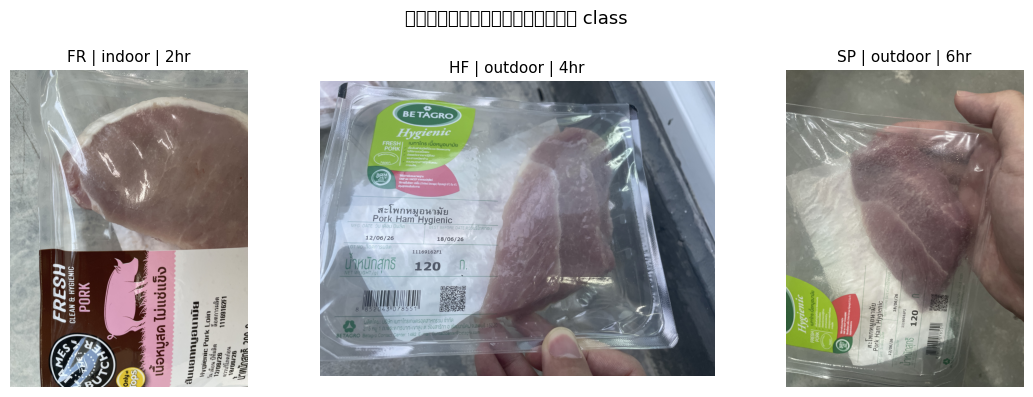

In [24]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Sanity checks
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
assert len(df) > 0, '❌ ไม่พบรูปเลย ตรวจ RAW_ROOT'
assert df['class_code'].nunique() <= 3, '❌ มี class เกิน 3'
assert df['new_name'].nunique() == len(df), '❌ ชื่อไฟล์ซ้ำกัน'

missing = [r for r in df['dest_path'] if not Path(r).exists()]
assert len(missing) == 0, f'❌ Copy ไม่ครบ: {missing[:5]}'

print('✅ Sanity checks ผ่านทั้งหมด')
print(f'   Total images : {len(df)}')
print(f'   Classes found: {sorted(df["class_code"].unique())}')
print(f'   Envs found   : {sorted(df["env"].unique())}')

# แสดงตัวอย่างรูป 1 รูปต่อ class
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, cls in zip(axes, ['FR', 'HF', 'SP']):
    subset = df[df['class_code'] == cls]
    if len(subset) == 0:
        ax.set_title(f'{cls} — ไม่มีรูป')
        continue
    sample = subset.sample(1, random_state=SEED).iloc[0]
    img = Image.open(sample['dest_path']).convert('RGB')
    ax.imshow(img)
    ax.set_title(f'{cls} | {sample["env"]} | {sample["hour"]}hr', fontsize=11)
    ax.axis('off')
plt.suptitle('ตัวอย่างรูปแต่ละ class', fontsize=13)
plt.tight_layout()
plt.savefig(str(out_root / 'sample_preview.png'), dpi=120)
plt.show()

## 4 · Load EfficientNet-B0 Checkpoint

In [25]:
import os

# ค้นหาไฟล์ .pth ทั้งหมดใน Drive
print("=== หาไฟล์ .pth ใน Drive ===")
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if f.endswith('.pth'):
            print(os.path.join(root, f))

=== หาไฟล์ .pth ใน Drive ===
/content/drive/MyDrive/FreshCheck/models/classification/phase1_efficientnet_b0_best.pth
/content/drive/MyDrive/FreshCheck/models/classification/phase2_swin_t_best.pth


In [26]:
NUM_CLASSES = 3
MODEL_DIR  = '/content/drive/MyDrive/FreshCheck/models/classification'
MODEL_NAME = 'phase1_efficientnet_b0_best.pth'

model_path = Path(MODEL_DIR) / MODEL_NAME
assert model_path.exists(), (
    f'❌ ไม่พบ model: {model_path}\n'
    f'   ตรวจ MODEL_DIR และ MODEL_NAME ใน Config cell\n'
    f'   (ไฟล์ .pth ควรอยู่จาก Phase 1 notebook)'
)

model = efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)

checkpoint = torch.load(model_path, map_location=DEVICE)
# รองรับทั้ง state_dict โดยตรง และ dict ที่มี key 'model_state_dict'
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f'   Loaded from checkpoint dict (epoch {checkpoint.get("epoch", "?")})')
else:
    model.load_state_dict(checkpoint)

model = model.to(DEVICE)
model.eval()
print(f'✅ Model loaded → {DEVICE}')

✅ Model loaded → cuda


## 5 · Dataset + DataLoader

In [27]:
# Transform เหมือน Phase 1 validation transform
test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

class ThaiTestDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['dest_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = int(row['class_idx'])
        return img, label, idx

dataset = ThaiTestDataset(df, transform=test_transform)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=2, pin_memory=(DEVICE=='cuda'))

print(f'✅ Dataset: {len(dataset)} รูป  |  {len(loader)} batches')

✅ Dataset: 441 รูป  |  14 batches


## 6 · Inference

In [28]:
from tqdm.auto import tqdm
import torch.nn.functional as F

all_probs   = []
all_preds   = []
all_labels  = []
all_indices = []

with torch.no_grad():
    for imgs, labels, indices in tqdm(loader, desc='Inference'):
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_indices.extend(indices.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print(f'✅ Inference เสร็จ')

# เพิ่มผลลงใน df
df_sorted = df.iloc[all_indices].copy().reset_index(drop=True)
df_sorted['pred_class']   = [IDX_TO_CLASS[p] for p in all_preds]
df_sorted['pred_idx']     = all_preds
df_sorted['prob_FR']      = all_probs[:, 0]
df_sorted['prob_HF']      = all_probs[:, 1]
df_sorted['prob_SP']      = all_probs[:, 2]
df_sorted['correct']      = df_sorted['class_idx'] == df_sorted['pred_idx']

Inference:   0%|          | 0/14 [00:00<?, ?it/s]

✅ Inference เสร็จ


## 7 · Metrics + Reports

In [29]:
CLASS_NAMES = ['FR', 'HF', 'SP']

print('=' * 60)
print('CLASSIFICATION REPORT — Thai Test Set')
print('=' * 60)
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    digits=4
))

acc = (all_labels == all_preds).mean()
print(f'Overall Accuracy: {acc:.4f} ({acc*100:.2f}%)')

# Breakdown by env
print('\n── Accuracy by Environment ──')
print(df_sorted.groupby('env')['correct'].mean().apply(lambda x: f'{x:.4f}').to_string())

# Breakdown by hour
print('\n── Accuracy by Hour ──')
print(df_sorted.groupby('hour')['correct'].mean().apply(lambda x: f'{x:.4f}').to_string())

CLASSIFICATION REPORT — Thai Test Set
              precision    recall  f1-score   support

          FR     0.3659    0.9615    0.5300       156
          HF     0.3667    0.0564    0.0978       195
          SP     0.0000    0.0000    0.0000        90

    accuracy                         0.3651       441
   macro avg     0.2442    0.3393    0.2093       441
weighted avg     0.2915    0.3651    0.2307       441

Overall Accuracy: 0.3651 (36.51%)

── Accuracy by Environment ──
env
indoor     0.4917
outdoor    0.2769

── Accuracy by Hour ──
hour
0    0.9487
1    0.9333
2    0.9861
3    0.0114
4    0.0000
5    0.2941
6    0.0000
7    0.0000


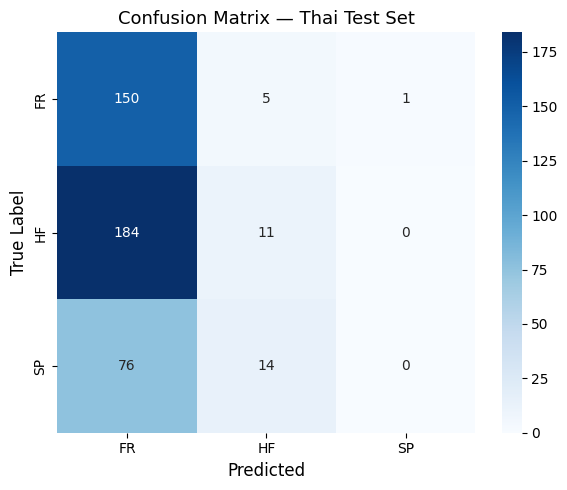

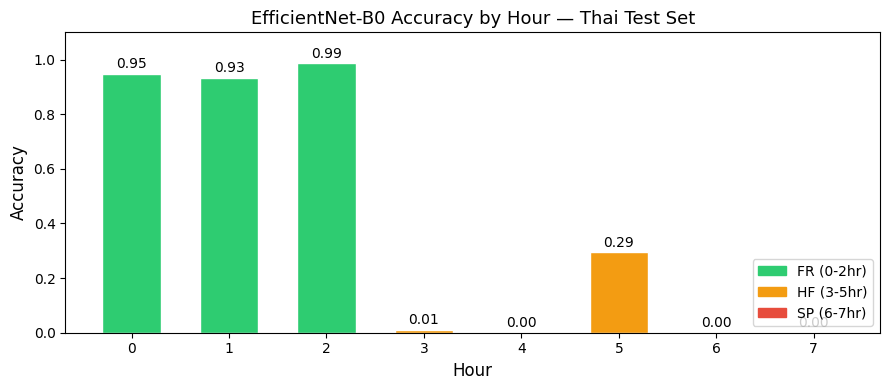

In [30]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — Thai Test Set', fontsize=13)
plt.tight_layout()
plt.savefig(str(out_root / 'thai_test_confusion_matrix.png'), dpi=150)
plt.show()

# Accuracy per hour chart
acc_by_hour = df_sorted.groupby('hour')['correct'].mean()
colors = ['#2ECC71' if h <= 2 else '#F39C12' if h <= 5 else '#E74C3C'
          for h in acc_by_hour.index]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(acc_by_hour.index, acc_by_hour.values, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, acc_by_hour.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10)

legend_patches = [
    mpatches.Patch(color='#2ECC71', label='FR (0-2hr)'),
    mpatches.Patch(color='#F39C12', label='HF (3-5hr)'),
    mpatches.Patch(color='#E74C3C', label='SP (6-7hr)'),
]
ax.legend(handles=legend_patches, loc='lower right')
ax.set_xlabel('Hour', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_xticks(acc_by_hour.index)
ax.set_title('EfficientNet-B0 Accuracy by Hour — Thai Test Set', fontsize=13)
plt.tight_layout()
plt.savefig(str(out_root / 'thai_test_accuracy_by_hour.png'), dpi=150)
plt.show()

## 8 · ดูรูปที่โมเดล Predict ผิด

รูปที่ predict ผิด: 280 / 441 (63.5%)


/tmp/ipykernel_5216/69527876.py:23: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5216/69527876.py:23: UserWarning: Glyph 3641 (\N{THAI CHARACTER SARA UU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5216/69527876.py:23: UserWarning: Glyph 3611 (\N{THAI CHARACTER PO PLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5216/69527876.py:23: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5216/69527876.py:23: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5216/69527876.py:23: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5216/69527876.py:23: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from font(s) DejaVu Sans.
  plt.tight

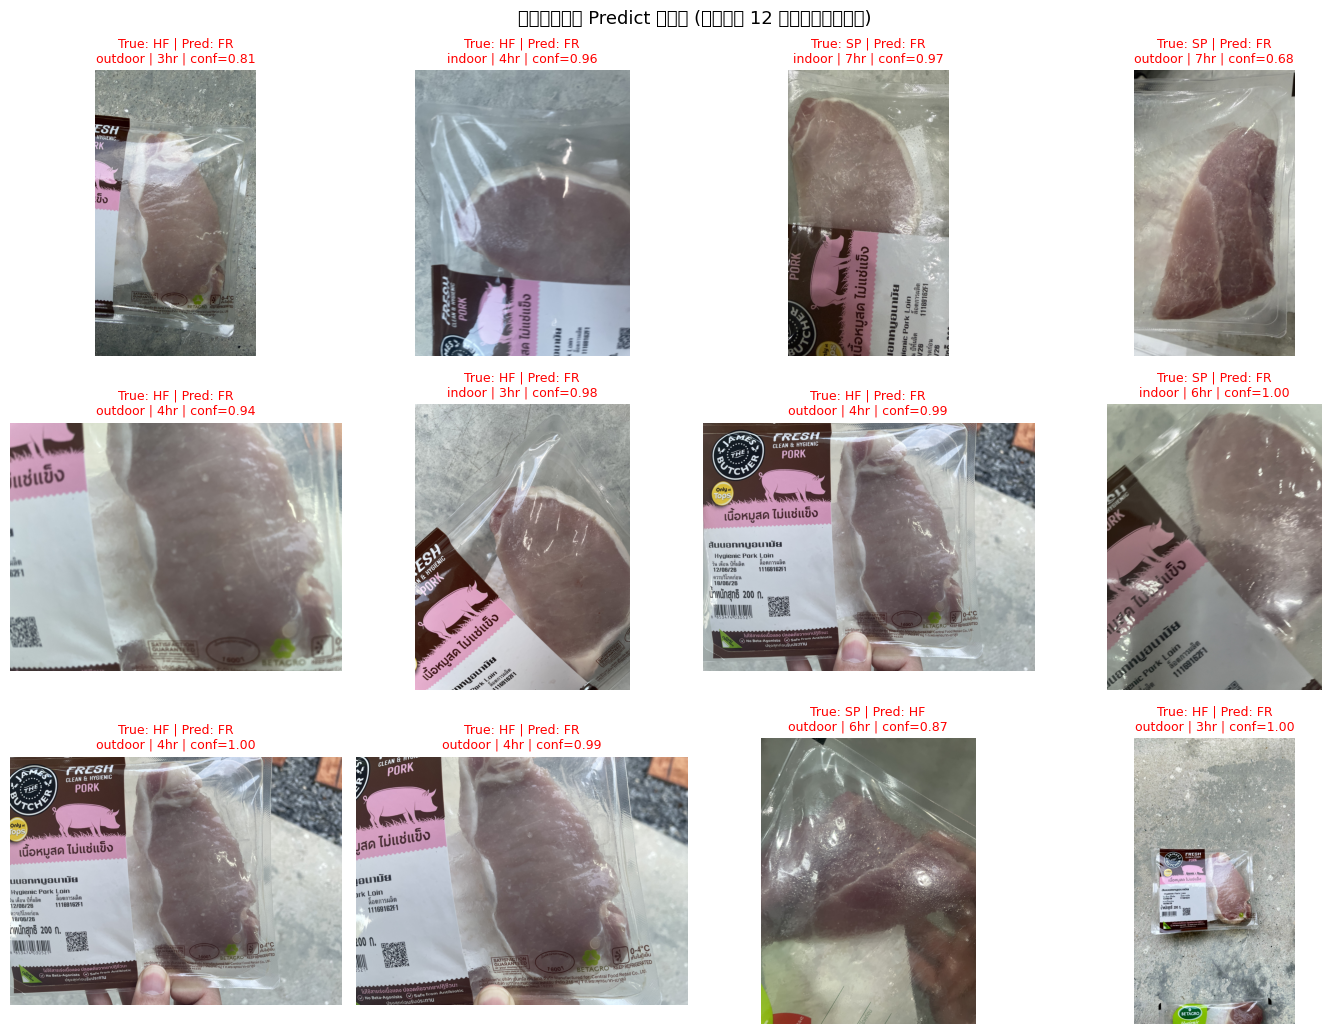

In [31]:
wrong = df_sorted[~df_sorted['correct']]
print(f'รูปที่ predict ผิด: {len(wrong)} / {len(df_sorted)} ({len(wrong)/len(df_sorted)*100:.1f}%)')

if len(wrong) > 0:
    n_show = min(12, len(wrong))
    samples = wrong.sample(n_show, random_state=SEED)
    cols = 4
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
    axes = axes.flatten()
    for ax, (_, row) in zip(axes, samples.iterrows()):
        img = Image.open(row['dest_path']).convert('RGB')
        ax.imshow(img)
        ax.set_title(
            f'True: {row["class_code"]} | Pred: {row["pred_class"]}\n'
            f'{row["env"]} | {row["hour"]}hr | conf={max(row["prob_FR"], row["prob_HF"], row["prob_SP"]):.2f}',
            fontsize=9, color='red'
        )
        ax.axis('off')
    for ax in axes[n_show:]:
        ax.axis('off')
    plt.suptitle(f'รูปที่ Predict ผิด (แสดง {n_show} ตัวอย่าง)', fontsize=13)
    plt.tight_layout()
    plt.savefig(str(out_root / 'thai_test_wrong_predictions.png'), dpi=120)
    plt.show()
else:
    print('🎉 โมเดล predict ถูกทุกรูป!')

## 9 · Export ผลลัพธ์

In [32]:
pred_csv = out_root / 'thai_test_predictions.csv'
df_sorted.to_csv(pred_csv, index=False)

print('✅ บันทึกผลลัพธ์ครบแล้ว:')
print(f'   {out_root}/thai_test_manifest.csv       ← manifest + metadata ทุกรูป')
print(f'   {out_root}/thai_test_predictions.csv    ← pred_class, prob_FR/HF/SP, correct')
print(f'   {out_root}/sample_preview.png')
print(f'   {out_root}/thai_test_confusion_matrix.png')
print(f'   {out_root}/thai_test_accuracy_by_hour.png')
print(f'   {out_root}/thai_test_wrong_predictions.png')

# Summary สำหรับ paste ใน Final Report
print('\n' + '=' * 60)
print('SUMMARY FOR FINAL REPORT')
print('=' * 60)
from sklearn.metrics import accuracy_score, f1_score
acc  = accuracy_score(all_labels, all_preds)
f1   = f1_score(all_labels, all_preds, average='macro')
f1w  = f1_score(all_labels, all_preds, average='weighted')
print(f'Thai Test Set (N={len(df_sorted)})')
print(f'  Accuracy       : {acc:.4f}')
print(f'  Macro F1       : {f1:.4f}')
print(f'  Weighted F1    : {f1w:.4f}')
print(f'  Model          : EfficientNet-B0 (Phase 1 checkpoint)')
print(f'  Label mapping  : 0-2hr=FR, 3-5hr=HF, 6-7hr=SP')

✅ บันทึกผลลัพธ์ครบแล้ว:
   /content/drive/MyDrive/FreshCheck/thai_test/thai_test_manifest.csv       ← manifest + metadata ทุกรูป
   /content/drive/MyDrive/FreshCheck/thai_test/thai_test_predictions.csv    ← pred_class, prob_FR/HF/SP, correct
   /content/drive/MyDrive/FreshCheck/thai_test/sample_preview.png
   /content/drive/MyDrive/FreshCheck/thai_test/thai_test_confusion_matrix.png
   /content/drive/MyDrive/FreshCheck/thai_test/thai_test_accuracy_by_hour.png
   /content/drive/MyDrive/FreshCheck/thai_test/thai_test_wrong_predictions.png

SUMMARY FOR FINAL REPORT
Thai Test Set (N=441)
  Accuracy       : 0.3651
  Macro F1       : 0.2093
  Weighted F1    : 0.2307
  Model          : EfficientNet-B0 (Phase 1 checkpoint)
  Label mapping  : 0-2hr=FR, 3-5hr=HF, 6-7hr=SP


In [33]:
import torch

ckpt = torch.load('/content/drive/MyDrive/FreshCheck/models/classification/phase2_swin_t_best.pth',
                   map_location='cpu')

# ดู key ทั้งหมด
if isinstance(ckpt, dict):
    print("Keys:", list(ckpt.keys()))
    # ถ้ามี config หรือ metadata
    for k in ckpt.keys():
        if k != 'model_state_dict' and k != 'state_dict':
            print(f"  {k}: {ckpt[k]}")
else:
    # เป็น state_dict โดยตรง
    keys = list(ckpt.keys())
    print("First 5 keys:", keys[:5])
    print("Last 5 keys:", keys[-5:])
    # ดู output layer size
    for k in keys:
        if 'head' in k or 'classifier' in k or 'fc' in k:
            print(f"  {k}: {ckpt[k].shape}")

เอาต์พุตของการสตรีมมีการตัดเหลือเพียง 5000 บรรทัดสุดท้าย
        [ 0.0623,  0.0608, -0.0907,  ..., -0.0207, -0.0210,  0.0082]])
  features.3.1.mlp.3.bias: tensor([ 7.5260e-02,  8.0603e-03, -8.4268e-02, -1.9354e-01,  2.5321e-01,
        -2.4261e-01,  2.1939e-02,  6.0414e-02,  1.5449e-01,  4.6219e-01,
        -1.4584e-02, -4.4887e-02,  9.4025e-02, -1.2127e-01, -2.2737e-02,
        -1.4836e-01, -1.1155e-01, -1.3724e-02,  3.1644e-01, -5.9773e-01,
        -2.7783e-02,  1.7129e-01,  4.1237e-01, -1.5815e-01,  3.0184e-01,
        -2.7485e-01, -8.8187e-02,  4.9971e-01,  1.2796e-01,  2.9789e-02,
         1.6880e-01, -3.1480e-01, -1.1034e-03, -2.7275e-02, -2.3410e-01,
        -8.5089e-02,  1.2777e-01, -4.0706e-01,  2.1418e-01, -2.0311e-01,
         3.6740e-01, -4.0546e-01,  9.1152e-02,  6.3474e-02,  3.2364e-01,
         2.0988e-01,  2.6423e-01,  1.7295e-01,  1.4178e-01, -3.5441e-01,
        -1.6965e-01,  4.1651e-01, -6.5156e-01, -1.0184e-01, -3.1318e-01,
        -7.5407e-02,  3.2007e-01, -1.2342e